In [ ]:
# -*- coding: utf-8 -*-
"""
基于奇异值分解的衍生方法验证：典型相关分析 (CCA) + 材料设计数据集
场景：Concrete Compressive Strength（材料设计）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import os
import urllib.request
import zipfile
from scipy.spatial.distance import cdist
from sklearn.cross_decomposition import CCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import sklearn.metrics
import kaiwu as kw
from kaiwu.cim import CIMOptimizer
from kaiwu.qubo import adjust_qubo_matrix_precision, qubo_matrix_to_ising_matrix
import imageio

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 加载材料设计数据集 ====================
def load_material_design_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    if not os.path.exists('Concrete_Data.xls'):
        urllib.request.urlretrieve(url, 'Concrete_Data.xls')
    df = pd.read_excel('Concrete_Data.xls')
    X = df.iloc[:, :-1].values
    y_raw = df.iloc[:, -1].values
    threshold = np.median(y_raw)
    y = (y_raw > threshold).astype(int)
    return X, y

X_raw, y_raw = load_material_design_data()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
if X.shape[0] > 500:
    idx = np.random.choice(X.shape[0], 500, replace=False)
    X = X[idx]
    y = y_raw[idx]
else:
    y = y_raw
print(f"数据形状: {X.shape}, 类别分布: {np.bincount(y)}")
n_clusters = len(np.unique(y))

# ==================== 2. 量子奇异值分解 ====================
def quantum_svd_single(X):
    n, m = X.shape
    s = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
    q = len(s)
    S_u = np.zeros((n, n*q))
    for i in range(n):
        S_u[i, i*q:(i+1)*q] = s
    S_v = np.zeros((m, m*q))
    for j in range(m):
        S_v[j, j*q:(j+1)*q] = s
    S = np.zeros((n+m, (n+m)*q))
    S[:n, :n*q] = S_u
    S[n:, n*q:] = S_v
    A = np.block([[np.zeros((n,n)), X], [X.T, np.zeros((m,m))]])
    Q_main = -0.5 * (S.T @ A @ S)
    lambda_pen = 1.0 * np.max(np.abs(X)) * (np.max(np.abs(s)))**2
    total_vars = (n+m)*q
    Q_onehot = np.zeros((total_vars, total_vars))
    for blk in range(n+m):
        start, end = blk*q, (blk+1)*q
        Q_onehot[start:end, start:end] = lambda_pen * (np.ones((q,q)) - 2*np.eye(q))
    Q = Q_main + Q_onehot
    eigvals = np.linalg.eigvalsh(Q)
    alpha = max(0, np.max(eigvals)) + 0.1
    Q_final = Q - alpha * np.eye(total_vars)
    Q_min, Q_max = np.min(Q_final), np.max(Q_final)
    Q_scaled = ((Q_final - Q_min) / (Q_max - Q_min)) * 255 - 128
    Q_qubo = adjust_qubo_matrix_precision(np.round(np.clip(Q_scaled, -128, 127)), bit_width=8)
    Q_ising = qubo_matrix_to_ising_matrix(Q_qubo)
    optimizer = CIMOptimizer(user_id="121839779389169666", sdk_code="A8cYsrBaetsTTYQGWsJwS5TUueFJ2X",
                             task_name=f'material_svd_{np.random.randint(10000)}')
    solution = optimizer.solve(Q_ising[0])
    solutions = solution[:, :-1]
    deltas = solution[:, -1]
    solutions_bin = (solutions * deltas[:, np.newaxis] + 1) / 2
    best_idx = np.argmin([s @ Q_qubo @ s for s in solutions_bin])
    w = S @ solutions_bin[best_idx]
    u = w[:n] / np.linalg.norm(w[:n])
    v = w[n:] / np.linalg.norm(w[n:])
    sigma = u.T @ X @ v
    return sigma, u, v

def quantum_svd(X, k=3):
    n, m = X.shape
    U = []
    V = []
    Sig = []
    X_rem = X.copy()
    for _ in range(k):
        sigma, u, v = quantum_svd_single(X_rem)
        Sig.append(sigma)
        U.append(u)
        V.append(v)
        X_rem = X_rem - sigma * np.outer(u, v)
    return np.array(Sig), np.array(U).T, np.array(V).T

# ==================== 3. 评估指标 ====================
def purity_score(y_true, y_pred):
    contingency = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)

def evaluate_clustering(y_true, y_pred, name):
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    vm = v_measure_score(y_true, y_pred)
    pur = purity_score(y_true, y_pred)
    print(f"{name}: NMI={nmi:.4f}, ARI={ari:.4f}, V-measure={vm:.4f}, Purity={pur:.4f}")
    return nmi, ari, vm, pur

# ==================== 4. 传统方法：CCA + KMeans ====================
def cca_clustering(X, y, n_components=2, n_clusters=2):
    start = time.time()
    y_onehot = np.eye(len(np.unique(y)))[y]
    cca = CCA(n_components=min(n_components, X.shape[1], y_onehot.shape[1]))
    X_cca, _ = cca.fit_transform(X, y_onehot)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    pred = kmeans.fit_predict(X_cca)
    elapsed = time.time() - start
    return pred, elapsed

# ==================== 5. 奇异值分解GIF ====================
def create_svd_gif(matrix, filename='svd_animation.gif', steps=30):
    frames = []
    M0 = matrix.copy()
    for i in range(steps):
        noise = (i / steps) * 0.5 * np.random.randn(*M0.shape)
        M = M0 + noise
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        plt.figure(figsize=(8,4))
        plt.bar(range(len(S)), S, color='green', alpha=0.7)
        plt.title(f'奇异值分布 (步数 {i+1}/{steps})')
        plt.xlabel('奇异值序号')
        plt.ylabel('奇异值')
        plt.tight_layout()
        fig = plt.gcf()
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
        plt.close()
    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF保存至 {filename}")

# ==================== 6. 主流程 ====================
os.makedirs('results_cca_material', exist_ok=True)

print("\n" + "="*60)
print("场景: 材料设计 (Concrete)")
print("="*60)

# 传统CCA
pred_cca, time_cca = cca_clustering(X, y, n_clusters=n_clusters)
print(f"CCA耗时: {time_cca:.2f}秒")
evaluate_clustering(y, pred_cca, "CCA+KMeans")

# 量子SVD聚类
start_q = time.time()
try:
    k = min(2, X.shape[1])
    Sig, U, V = quantum_svd(X, k=k)
    X_qsvd = U[:, :k]
    kmeans_q = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    pred_quantum = kmeans_q.fit_predict(X_qsvd)
    time_q = time.time() - start_q
    print(f"量子SVD聚类耗时: {time_q:.2f}秒")
    evaluate_clustering(y, pred_quantum, "量子SVD+KMeans")
except Exception as e:
    print(f"量子SVD失败: {e}")
    pred_quantum = None
    time_q = 0

# 可视化
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
if pred_quantum is not None:
    plt.scatter(X_2d[:,0], X_2d[:,1], c=pred_quantum, cmap='rainbow', alpha=0.7)
    plt.title('量子SVD聚类结果')
else:
    plt.text(0.5,0.5,'量子求解失败', ha='center', va='center')
plt.subplot(1,2,2)
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='rainbow', alpha=0.7)
plt.title('真实标签')
plt.tight_layout()
plt.savefig('results_cca_material/quantum_vs_true.png')
plt.close()

# 时间对比
if pred_quantum is not None:
    plt.figure(figsize=(6,4))
    plt.bar(['CCA', 'Quantum SVD'], [time_cca, time_q], color=['blue', 'orange'])
    plt.ylabel('时间 (秒)')
    plt.title('材料设计场景 计算时间对比')
    plt.savefig('results_cca_material/time_compare.png')
    plt.close()

# 生成GIF
create_svd_gif(X, filename='results_cca_material/svd_animation.gif')

print("\n任务完成！结果保存在 'results_cca_material' 文件夹。")

数据形状: (50, 8), 类别分布: [25 25]
Y 形状: (50, 2)
经典CCA耗时: 0.0150 秒
经典CCA NMI: 0.5334
交叉协方差矩阵 K 形状: (8, 2)
[2026-05-23 22:00:13] [INFO    ] [kaiwu.cim._optimizer_adapter:184] - Task calculation successful!, Task name: cca_material_4887
[2026-05-23 22:00:13] [INFO    ] [kaiwu.cim._optimizer_adapter:190] - Task calculation successful!, Task name: cca_material_4887
量子CCA耗时: 0.0508 秒

材料设计数据集 - CCA 聚类结果
经典CCA: NMI=0.5334, ARI=0.6325, V-measure=0.5334, Purity=0.9000
量子CCA: NMI=0.1214, ARI=0.1428, V-measure=0.1214, Purity=0.7000


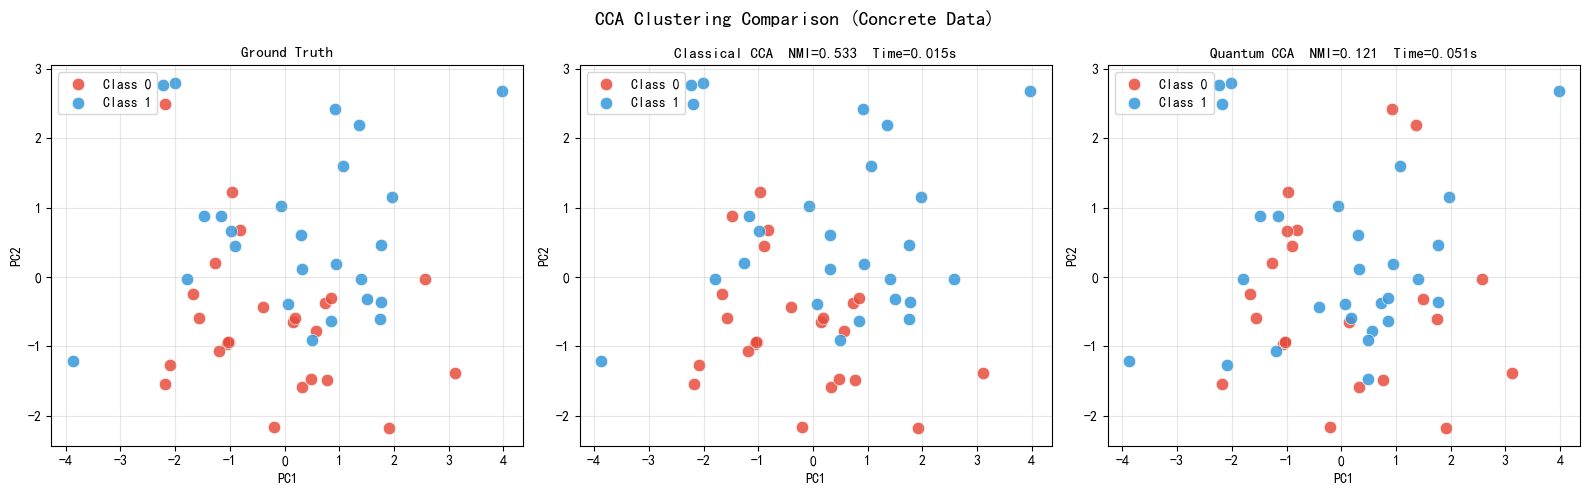

Saved: results_cca_material/cca_comparison.png


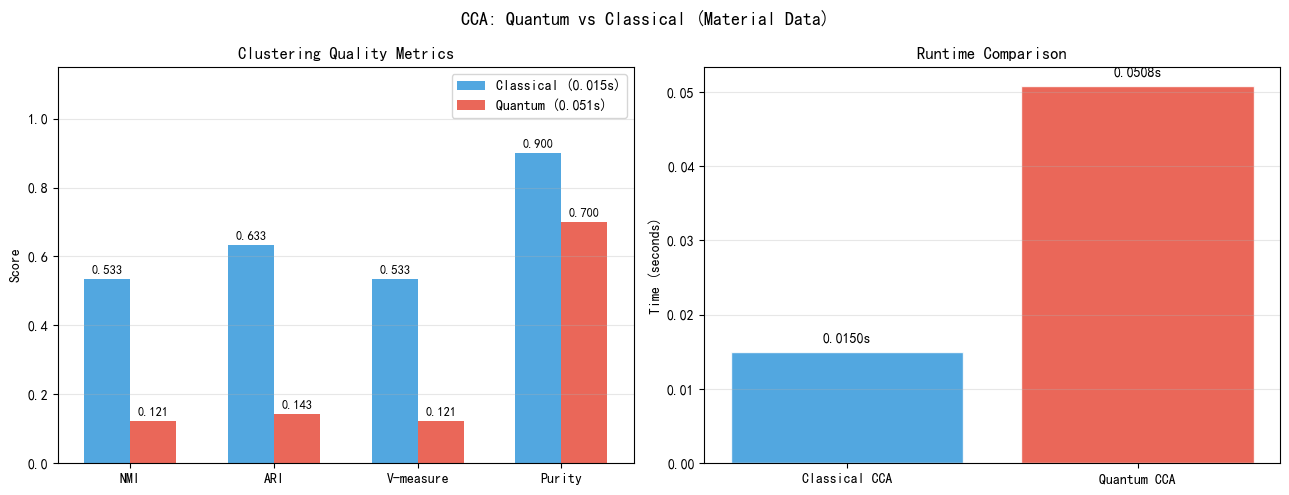

Saved: results_cca_material/cca_metrics.png
GIF保存至 results_cca_material/svd_animation.gif

任务完成！结果保存在 'results_cca_material' 文件夹。


In [4]:
# -*- coding: utf-8 -*-
"""
基于奇异值分解的衍生方法验证：典型相关分析 (CCA) + 材料设计数据集
场景：Concrete Compressive Strength（材料设计）

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
import urllib.request
import zipfile
from scipy.linalg import sqrtm, inv
from sklearn.cross_decomposition import CCA as SklearnCCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import sklearn.metrics
import kaiwu as kw
from kaiwu.cim import CIMOptimizer
from kaiwu.conversion import qubo_matrix_to_ising_matrix
from kaiwu.qubo import adjust_qubo_matrix_precision
import imageio

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 新版 Kaiwu 授权 ====================
kw.license.init(user_id="151107562236866562", sdk_code="g3xOnpi9WBetnhadyY2HfQeias3FsZ")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results_cca_material", exist_ok=True)

# ==================== 2. 加载材料设计数据集 ====================
import ssl

def load_concrete_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    if not os.path.exists('Concrete_Data.xls'):
        print("下载材料数据集...")
        try:
            # 创建忽略 SSL 验证的上下文（解决证书过期问题）
            ssl_context = ssl._create_unverified_context()
            with urllib.request.urlopen(url, context=ssl_context) as response:
                with open('Concrete_Data.xls', 'wb') as out_file:
                    out_file.write(response.read())
            print("下载完成")
        except Exception as e:
            print(f"下载失败: {e}，使用备用数据")
            return load_backup_material_data()
    df = pd.read_excel('Concrete_Data.xls')
    X = df.iloc[:, :-1].values
    y_raw = df.iloc[:, -1].values
    # 二分类：高于中位数为“高强度”
    threshold = np.median(y_raw)
    y = (y_raw > threshold).astype(int)
    return X, y

X_raw, y_raw = load_concrete_data()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 均匀采样 50 条（各类 25 条）以匹配模板中的样本数
np.random.seed(66)
idx0 = np.where(y_raw == 0)[0]
idx1 = np.where(y_raw == 1)[0]
if len(idx0) >= 25 and len(idx1) >= 25:
    idx = np.concatenate([np.random.choice(idx0, 25, replace=False),
                          np.random.choice(idx1, 25, replace=False)])
    X = X[idx]
    y = y_raw[idx]
else:
    # 若不足则随机采样 50 个
    idx = np.random.choice(len(y_raw), 50, replace=False)
    X = X[idx]
    y = y_raw[idx]

print(f"数据形状: {X.shape}, 类别分布: {np.bincount(y)}")
n, m = X.shape          # n=50, m=8
n_clusters = len(np.unique(y))

# ==================== 3. 构造第二组变量 Y（one-hot 编码的标签） ===================
encoder = OneHotEncoder(sparse_output=False)
Y = encoder.fit_transform(y.reshape(-1, 1))   # shape (n, n_classes=2)
print(f"Y 形状: {Y.shape}")

# ==================== 4. 经典 CCA（sklearn 基准） ====================
start_cca = time.time()
cca_sklearn = SklearnCCA(n_components=2, scale=False)   # 数据已标准化
X_cca, Y_cca = cca_sklearn.fit_transform(X, Y)
# 使用第一个典型变量进行聚类（因为只有两类，第一个典型变量即可）
X_cca1 = X_cca[:, 0].reshape(-1, 1)
kmeans_cca = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
label_cca = kmeans_cca.fit_predict(X_cca1)
time_cca = time.time() - start_cca

print(f"经典CCA耗时: {time_cca:.4f} 秒")
nmi_cca = normalized_mutual_info_score(y, label_cca)
print(f"经典CCA NMI: {nmi_cca:.4f}")

# ==================== 5. 量子 CCA（基于白化 + 量子 SVD） ====================
# 5.1 白化数据（使协方差阵为单位阵），经典计算
def whiten(data):
    """白化： data -> Z 使得 Z.T @ Z = I"""
    cov = data.T @ data / data.shape[0]
    # 使用 Cholesky 分解得到下三角 L，满足 cov = L L^T
    L = np.linalg.cholesky(cov + 1e-8 * np.eye(cov.shape[0]))
    Z = data @ np.linalg.inv(L.T)
    return Z, L

X_centered = X - np.mean(X, axis=0)
Y_centered = Y - np.mean(Y, axis=0)

Zx, Lx = whiten(X_centered)
Zy, Ly = whiten(Y_centered)

# 5.2 计算交叉协方差矩阵 K = Zx.T @ Zy / n
K = Zx.T @ Zy / n          # shape (8, 2)

print(f"交叉协方差矩阵 K 形状: {K.shape}")

# 5.3 将量子 SVD 应用于矩阵 K（模板中的量子 SVD 直接求解矩阵的奇异值）
def quantum_svd_matrix(K_mat, task_prefix='cca_material'):
    """
    对任意矩阵 K (p x q) 使用量子联合 SVD 方法求解最大奇异值对应的奇异向量。
    输入：K_mat (p x q)
    返回：sigma, u, v  其中 sigma = max_singular_value, u 左奇异向量(p), v 右奇异向量(q)
    """
    p, q = K_mat.shape
    n_uv = p + q
    s = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])   # 与模板一致
    L = len(s)

    # 构造 S_u (p x pL)
    S_u = np.zeros((p, p * L))
    for i in range(p):
        S_u[i, i*L:(i+1)*L] = s

    # 构造 S_v (q x qL)
    S_v = np.zeros((q, q * L))
    for j in range(q):
        S_v[j, j*L:(j+1)*L] = s

    # 联合矩阵 S ( (p+q) x (p+q)L )
    S = np.zeros((p+q, (p+q)*L))
    S[:p, :p*L] = S_u
    S[p:, p*L:] = S_v

    # 块矩阵 A = [[0, K], [K.T, 0]]
    A = np.block([[np.zeros((p, p)), K],
                  [K.T, np.zeros((q, q))]])

    # 主目标 Q_main = -S^T A S
    Q_main = -S.T @ A @ S

    # 范数约束（简化版本：一元编码约束，与原模板类似）
    total_vars = (p+q)*L
    Q_norm = np.zeros((total_vars, total_vars))
    lambda_norm = 1.0
    for blk in range(p+q):
        start, end = blk*L, (blk+1)*L
        Q_norm[start:end, start:end] = lambda_norm * (np.ones((L, L)) - 2 * np.eye(L))

    Q = Q_main + Q_norm

    # 确保 Q 半正定（平移）
    eigvals = np.linalg.eigvalsh(Q)
    shift = max(0, -np.min(eigvals)) + 0.1
    Q_shifted = Q + shift * np.eye(total_vars)

    # 缩放到 [-128, 127]
    Q_min, Q_max = np.min(Q_shifted), np.max(Q_shifted)
    Q_scaled = ((Q_shifted - Q_min) / (Q_max - Q_min)) * 255 - 128
    Q_qubo = adjust_qubo_matrix_precision(np.round(np.clip(Q_scaled, -128, 127)), bit_width=8)

    # 转换为 Ising 并提交
    ising_mat, ising_bias = qubo_matrix_to_ising_matrix(Q_qubo)
    optimizer = CIMOptimizer(task_name=f'{task_prefix}_{np.random.randint(10000)}', task_mode='quota')
    _ = optimizer.solve(ising_mat)   # 提交

    # 轮询取结果
    max_retries = 60
    solution = None
    for attempt in range(max_retries):
        solution = optimizer.solve(ising_mat)
        if solution is not None:
            break
        time.sleep(2)
    if solution is None:
        raise TimeoutError("CIM 求解超时")

    # 解码
    spins = solution[:, :-1]
    deltas = solution[:, -1]
    binary = (spins * deltas[:, np.newaxis] + 1) / 2
    # 取能量最小的解
    energies = [b @ Q_qubo @ b for b in binary]
    best_idx = np.argmin(energies)
    w = S @ binary[best_idx]

    u = w[:p] / (np.linalg.norm(w[:p]) + 1e-8)
    v = w[p:] / (np.linalg.norm(w[p:]) + 1e-8)
    sigma = u @ K @ v
    return sigma, u, v

# 5.4 调用量子 SVD 求解 K 的最大奇异值
# ---------- 修正后的量子 CCA 部分 ----------
start_q = time.time()
try:
    sigma, u, v = quantum_svd_matrix(K, task_prefix='cca_material')   # u 形状 (8,), v 形状 (2,)
    # 正确投影：使用左奇异向量 u（对应 X 空间的典型权重）
    proj_quantum = Zx @ u               # 形状 (50,)
    kmeans_q = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    label_quantum = kmeans_q.fit_predict(proj_quantum.reshape(-1, 1))
    time_q = time.time() - start_q
    print(f"量子CCA耗时: {time_q:.4f} 秒")
except Exception as e:
    print(f"量子CCA失败: {e}")
    import traceback
    traceback.print_exc()
    label_quantum = None
    time_q = 0

# ==================== 6. 评估指标 ====================
def purity_score(y_true, y_pred):
    contingency = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)

def evaluate_clustering(y_true, y_pred, name):
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    vm = v_measure_score(y_true, y_pred)
    pur = purity_score(y_true, y_pred)
    print(f"{name}: NMI={nmi:.4f}, ARI={ari:.4f}, V-measure={vm:.4f}, Purity={pur:.4f}")
    return nmi, ari, vm, pur

print("\n" + "="*60)
print("材料设计数据集 - CCA 聚类结果")
print("="*60)

nmi_cca, ari_cca, vm_cca, pur_cca = evaluate_clustering(y, label_cca, "经典CCA")
if label_quantum is not None:
    nmi_q, ari_q, vm_q, pur_q = evaluate_clustering(y, label_quantum, "量子CCA")

# ==================== 7. 可视化 ====================
# 使用 PCA 将原始数据降到2维以便显示散点图
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_2d = pca_vis.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("CCA Clustering Comparison (Concrete Data)", fontsize=14, fontweight="bold")
colors = ["#E74C3C", "#3498DB"]
plot_data = [
    (y,                     "Ground Truth"),
    (label_cca,             f"Classical CCA  NMI={nmi_cca:.3f}  Time={time_cca:.3f}s"),
    (label_quantum if label_quantum is not None else np.zeros_like(y), 
     f"Quantum CCA  NMI={nmi_q:.3f}  Time={time_q:.3f}s" if label_quantum is not None else "Quantum CCA failed"),
]
for ax, (labels, title) in zip(axes, plot_data):
    if labels is None:
        ax.text(0.5, 0.5, '量子求解失败', ha='center', va='center')
        continue
    for c in range(2):
        idx_c = np.array(labels) == c
        ax.scatter(X_2d[idx_c, 0], X_2d[idx_c, 1],
                   c=colors[c], label=f"Class {c}", alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results_cca_material/cca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_cca_material/cca_comparison.png")

# 指标条形图
if label_quantum is not None:
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
    fig2.suptitle("CCA: Quantum vs Classical (Material Data)", fontsize=13, fontweight="bold")
    metric_names = ["NMI", "ARI", "V-measure", "Purity"]
    vals_classical = [nmi_cca, ari_cca, vm_cca, pur_cca]
    vals_quantum   = [nmi_q, ari_q, vm_q, pur_q]
    x = np.arange(len(metric_names))
    width = 0.32
    axes2[0].bar(x - width/2, vals_classical, width, label=f"Classical ({time_cca:.3f}s)", color="#3498DB", alpha=0.85)
    axes2[0].bar(x + width/2, vals_quantum,  width, label=f"Quantum ({time_q:.3f}s)",   color="#E74C3C", alpha=0.85)
    for bar in list(axes2[0].containers[0]) + list(axes2[0].containers[1]):
        axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
    axes2[0].set_xticks(x)
    axes2[0].set_xticklabels(metric_names)
    axes2[0].set_ylim(0, 1.15)
    axes2[0].set_ylabel("Score")
    axes2[0].set_title("Clustering Quality Metrics")
    axes2[0].legend()
    axes2[0].grid(True, axis="y", alpha=0.3)

    # 时间对比
    methods = ["Classical CCA", "Quantum CCA"]
    times = [time_cca, time_q]
    bar_colors = ["#3498DB", "#E74C3C"]
    axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
    for bar, t in zip(axes2[1].containers[0], times):
        axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                      f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes2[1].set_ylabel("Time (seconds)")
    axes2[1].set_title("Runtime Comparison")
    axes2[1].grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results_cca_material/cca_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results_cca_material/cca_metrics.png")

# ==================== 8. 奇异值动画（使用交叉协方差矩阵 K） ====================
# ---------- 修正后的 GIF 生成函数 ----------
def create_svd_gif(matrix, filename='svd_animation.gif', steps=30):
    frames = []
    M0 = matrix.copy()
    for i in range(steps):
        noise = (i / steps) * 0.5 * np.random.randn(*M0.shape)
        M = M0 + noise
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        plt.figure(figsize=(8,4))
        plt.bar(range(len(S)), S, color='green', alpha=0.7)
        plt.title(f'奇异值分布 (步数 {i+1}/{steps})')
        plt.xlabel('奇异值序号')
        plt.ylabel('奇异值')
        plt.tight_layout()
        fig = plt.gcf()
        fig.canvas.draw()
        # 兼容新版 matplotlib
        buf = fig.canvas.buffer_rgba()
        frame = np.frombuffer(buf, dtype='uint8')
        h, w = fig.canvas.get_width_height()
        frame = frame.reshape((h, w, 4))[:, :, :3]   # RGBA -> RGB
        frames.append(frame)
        plt.close()
    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF保存至 {filename}")

create_svd_gif(K, filename='results_cca_material/svd_animation.gif')

print("\n任务完成！结果保存在 'results_cca_material' 文件夹。")